<a href="https://colab.research.google.com/github/200612780/Google-Colab/blob/main/Assignment_1_AIDI1005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PART-1**

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()


Saving train_bureau_raw.csv to train_bureau_raw.csv


In [2]:
df = pd.read_csv("train_bureau_raw.csv")

In [3]:
print(df.shape)

(307511, 302)


In [4]:
df.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,client_bureau_balance_STATUS_X_count_mean,client_bureau_balance_STATUS_X_count_max,client_bureau_balance_STATUS_X_count_min,client_bureau_balance_STATUS_X_count_sum,client_bureau_balance_STATUS_X_count_norm_mean,client_bureau_balance_STATUS_X_count_norm_max,client_bureau_balance_STATUS_X_count_norm_min,client_bureau_balance_STATUS_X_count_norm_sum,client_counts,TARGET
0,100002,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,...,1.875,3.0,0.0,15.0,0.161932,0.5,0.0,1.295455,8.0,1
1,100003,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.000000,0.0,0
2,100004,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.000000,0.0,0
3,100006,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,100007,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.000000,0.0,0


In [5]:
print(df.info())
print("\nTARGET column exists:", "TARGET" in df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 302 entries, SK_ID_CURR to TARGET
dtypes: float64(245), int64(41), object(16)
memory usage: 708.5+ MB
None

TARGET column exists: True


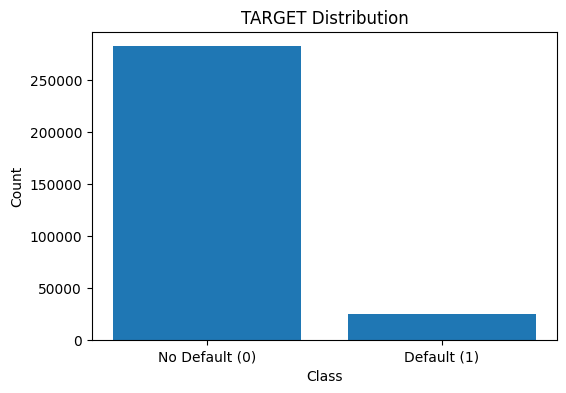

TARGET
0    282686
1     24825
Name: count, dtype: int64


In [6]:
# Target distribution
target_counts = df["TARGET"].value_counts().sort_index()

# Bar Chart of target distribution
plt.figure(figsize=(6,4))
plt.bar(["No Default (0)", "Default (1)"], target_counts.values)
plt.title("TARGET Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(target_counts)

Columns > 40% missing: 118


,0
bureau_AMT_ANNUITY_max,73.981744
bureau_AMT_ANNUITY_mean,73.981744
bureau_AMT_ANNUITY_min,73.981744
client_bureau_balance_STATUS_5_count_norm_min,70.007252
client_bureau_balance_STATUS_5_count_norm_mean,70.007252
client_bureau_balance_STATUS_5_count_norm_max,70.007252
client_bureau_balance_STATUS_5_count_max,70.007252
client_bureau_balance_STATUS_5_count_mean,70.007252
client_bureau_balance_STATUS_4_count_norm_min,70.007252
client_bureau_balance_STATUS_4_count_norm_max,70.007252


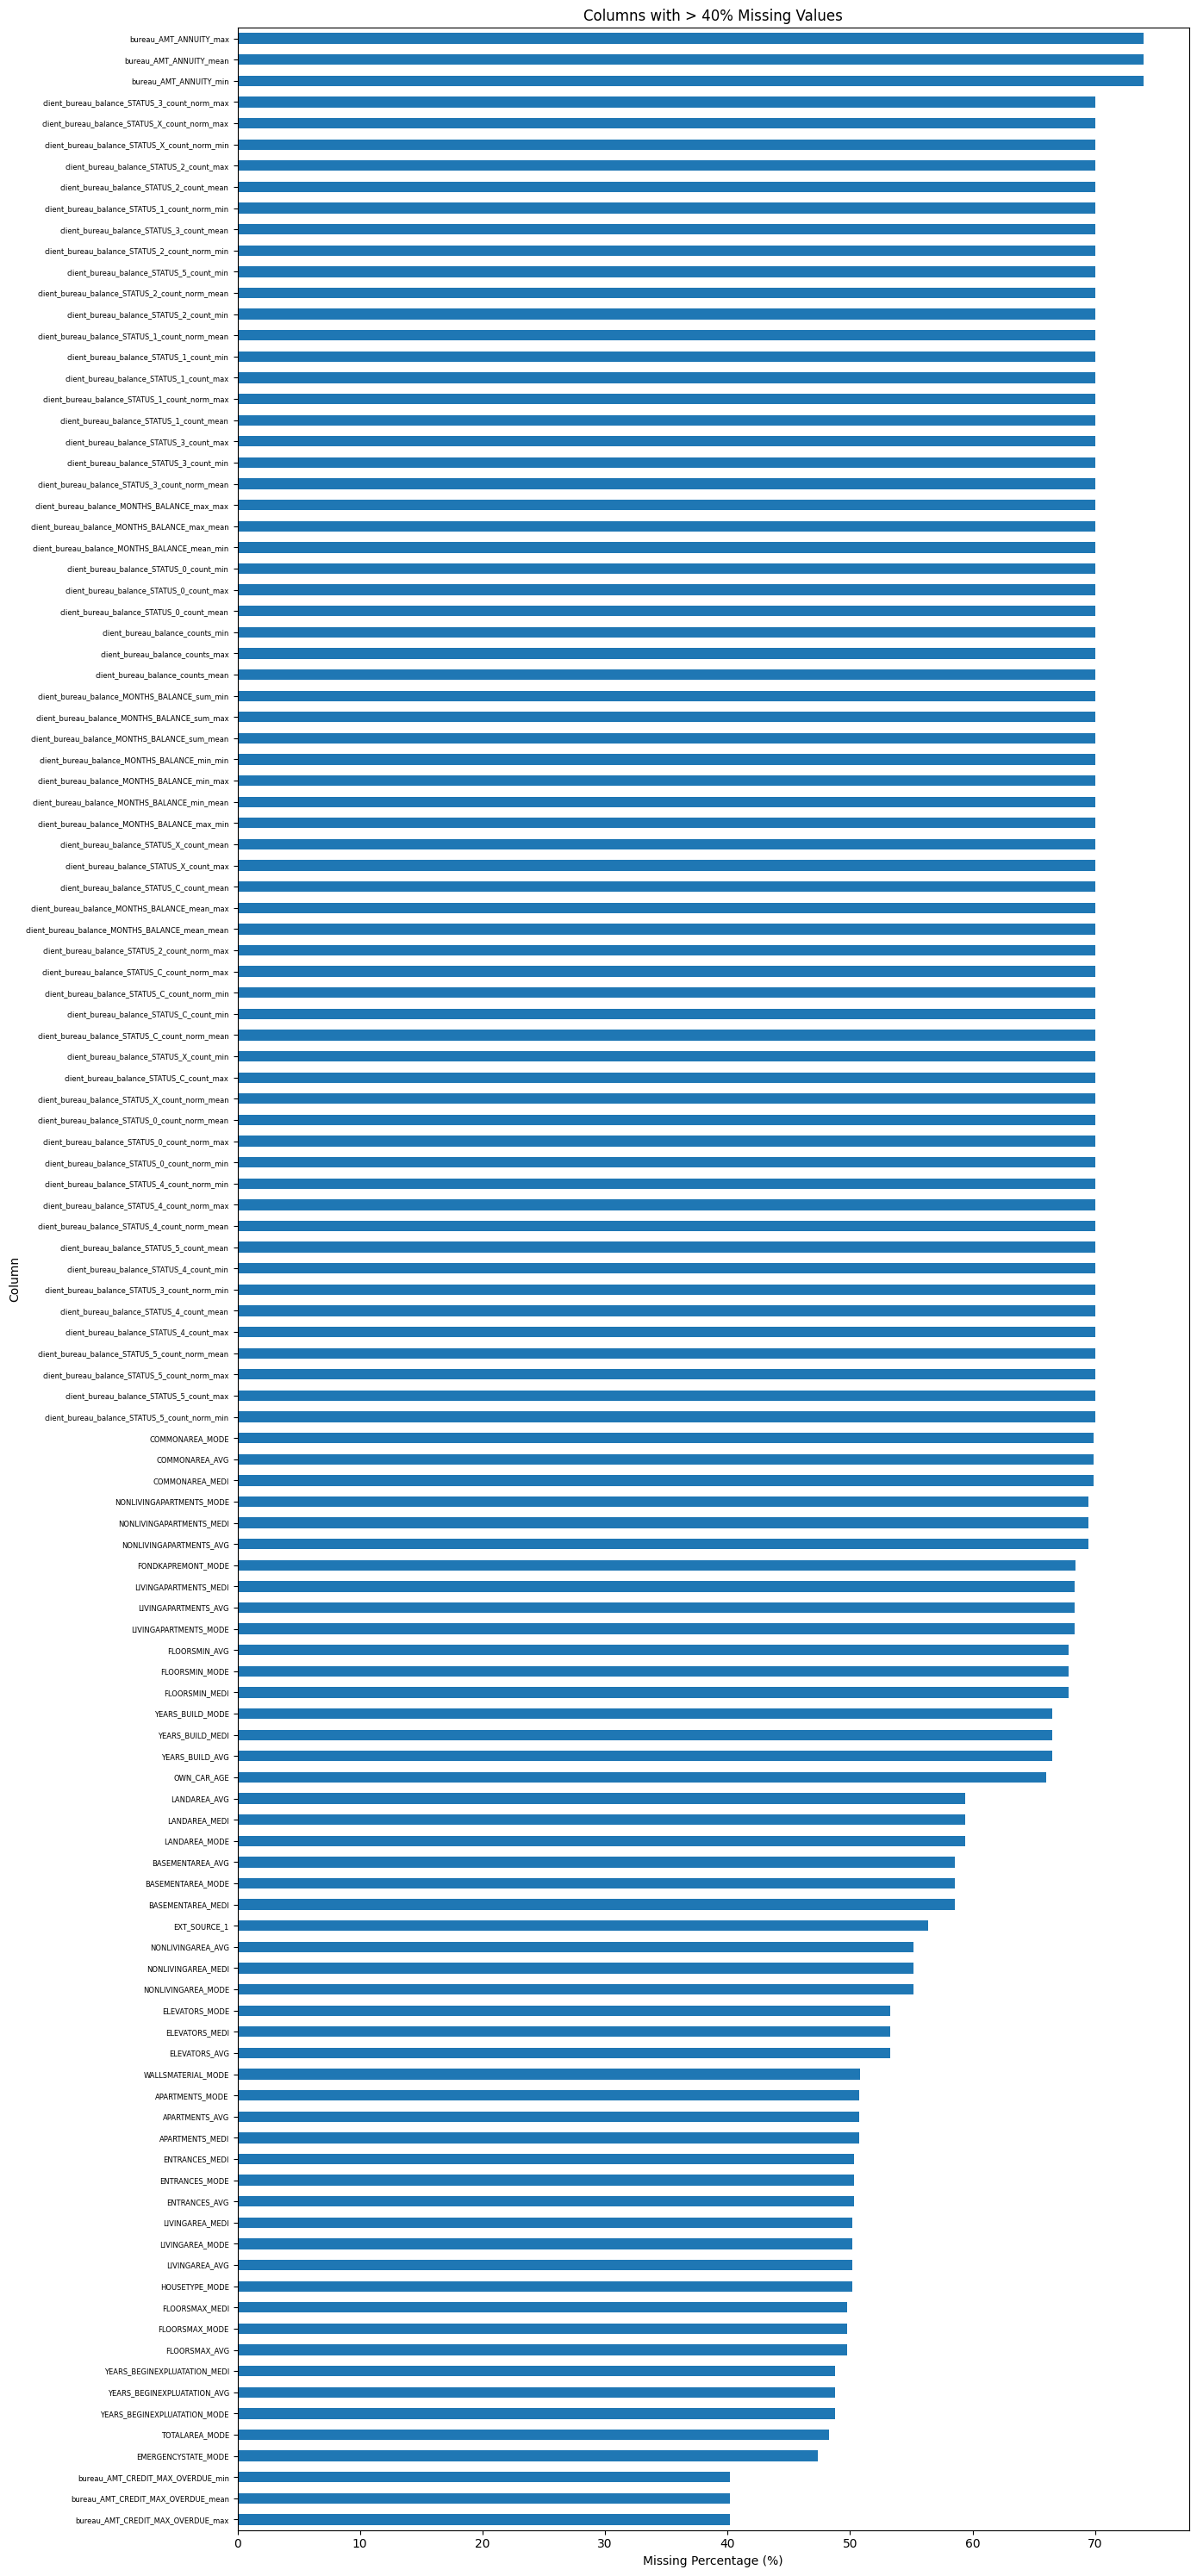

In [7]:
# Calculating missing percentage for each column
missing_percent = df.isna().mean() * 100

missing_40 = missing_percent[missing_percent > 40].sort_values(ascending=False)

print("Columns > 40% missing:", len(missing_40))

# Displaying top 20 columns
display(missing_40.head(20))

# Plotting columns with >40% missing values
plt.figure(figsize=(14, 30))
missing_40.sort_values().plot(kind="barh")

plt.title("Columns with > 40% Missing Values")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Column")

plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

**Business Justification**

Many columns have more than 40% missing values because many clients are unbanked and do not have full bureau history.If a feature is missing for most customers, it becomes unreliable and requires heavy imputation, which can reduce accuracy and increase bias. Also, keeping these features increases model complexity and cost. So i Decided to drop columns with more than 40% missing values to keep the model simpler, faster, and easier to explain.

In [8]:
# Dropping columns with more than 40% missing values
df1 = df.drop(columns=missing_40.index)

print("Before:", df.shape)
print("After dropping >40% missing:", df1.shape)


Before: (307511, 302)
After dropping >40% missing: (307511, 184)


In [9]:
# Taking only numeric columns
num = df1.select_dtypes(include=["int64", "float64"]).drop(columns=["TARGET"])

# Correlation matrix
corr = num.corr()

# Keep only the upper triangle to avoid duplicate pairs
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Convert into feature pairs
pairs = upper.stack().reset_index()
pairs.columns = ["col1", "col2", "corr"]

# Filter high correlation pairs (>0.9)
high = pairs[pairs["corr"].abs() > 0.9].sort_values(by="corr", key=lambda s: s.abs(), ascending=False)

print("High correlation pairs found:", len(high))
display(high.head(20))



High correlation pairs found: 30


,col1,col2,corr
11669,bureau_CREDIT_TYPE_Mobile operator loan_count,bureau_CREDIT_TYPE_Mobile operator loan_count_...,1.000000
10727,bureau_CREDIT_TYPE_Interbank credit_count,bureau_CREDIT_TYPE_Interbank credit_count_norm,1.000000
9123,bureau_CREDIT_CURRENCY_currency 1_count,bureau_counts,0.999808
1335,DAYS_EMPLOYED,FLAG_EMP_PHONE,-0.999755
4404,OBS_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.998490
8305,bureau_CREDIT_ACTIVE_Active_count_norm,bureau_CREDIT_ACTIVE_Closed_count_norm,-0.992232
13217,bureau_CNT_CREDIT_PROLONG_max,bureau_CNT_CREDIT_PROLONG_sum,0.988567
12528,bureau_CREDIT_DAY_OVERDUE_max,bureau_CREDIT_DAY_OVERDUE_sum,0.987884
508,AMT_CREDIT,AMT_GOODS_PRICE,0.986968
14067,client_bureau_balance_MONTHS_BALANCE_mean_sum,client_bureau_balance_MONTHS_BALANCE_min_sum,0.982719


In [10]:
# Droping one feature from each highly correlated pair
drop_cols = set(high["col2"])

df2 = df1.drop(columns=list(drop_cols))

print("Columns dropped because of high correlation:", len(drop_cols))
print("Shape before:", df1.shape)
print("Shape after:", df2.shape)


Columns dropped because of high correlation: 24
Shape before: (307511, 184)
Shape after: (307511, 160)


In [11]:
# Separating target variable (TARGET) from feature matrix
y = df2["TARGET"]
X = df2.drop(columns=["TARGET"])

# filling missing values
for c in X.columns:
    if X[c].dtype == "object":
        X[c] = X[c].fillna("Unknown")
    else:
        X[c] = X[c].fillna(X[c].median())

print("Missing values left:", X.isna().sum().sum())


Missing values left: 0


Missing Value Imputation : Machine learning models cannot handle missing values directly. We apply Median imputation for numeric features (robust to outliers) and "Unknown" category for categorical features.
This ensures no information loss while keeping preprocessing simple and explainable.

In [12]:
# Converting categorical variables into numeric format
X2 = pd.get_dummies(X, drop_first=True)

print("Shape after encoding:", X2.shape)
X2.head()


Shape after encoding: (307511, 261)


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,...,ORGANIZATION_TYPE_Trade: type 4,ORGANIZATION_TYPE_Trade: type 5,ORGANIZATION_TYPE_Trade: type 6,ORGANIZATION_TYPE_Trade: type 7,ORGANIZATION_TYPE_Transport: type 1,ORGANIZATION_TYPE_Transport: type 2,ORGANIZATION_TYPE_Transport: type 3,ORGANIZATION_TYPE_Transport: type 4,ORGANIZATION_TYPE_University,ORGANIZATION_TYPE_XNA
0,100002,0,202500.0,406597.5,24700.5,0.018801,-9461,-637,-3648.0,-2120,...,False,False,False,False,False,False,False,False,False,False
1,100003,0,270000.0,1293502.5,35698.5,0.003541,-16765,-1188,-1186.0,-291,...,False,False,False,False,False,False,False,False,False,False
2,100004,0,67500.0,135000.0,6750.0,0.010032,-19046,-225,-4260.0,-2531,...,False,False,False,False,False,False,False,False,False,False
3,100006,0,135000.0,312682.5,29686.5,0.008019,-19005,-3039,-9833.0,-2437,...,False,False,False,False,False,False,False,False,False,False
4,100007,0,121500.0,513000.0,21865.5,0.028663,-19932,-3038,-4311.0,-3458,...,False,False,False,False,False,False,False,False,False,False


**Encoding Categorical Variables**

Machine learning models cannot understand text values like “Active” or “Closed”. So, we convert categorical columns into numbers using One-Hot Encoding. One-Hot Encoding creates separate 0/1 columns for each category.  
This helps the model treat each category as its own signal without assuming
that one category is bigger or better than another. This makes the data usable for the model while keeping the information clear and meaningful.

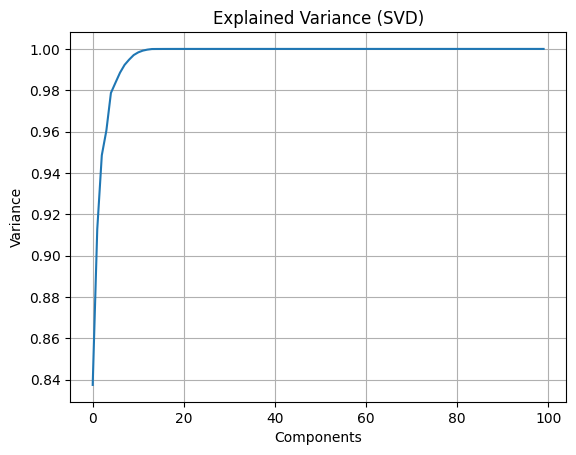

50 comps: 0.9999999999993241
100 comps: 0.9999999999999355


In [13]:
# Applying Truncated SVD to analyze dimensionality reduction
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=100, random_state=42)
svd.fit(X2)

# Calculating cumulative explained variance
exp = np.cumsum(svd.explained_variance_ratio_)

plt.plot(exp)
plt.title("Explained Variance (SVD)")
plt.xlabel("Components")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

print("50 comps:", exp[49])
print("100 comps:", exp[99])

# Code partially generated using ChatGPT prompt: "How to apply Truncated SVD in sklearn and plot cumulative explained variance?"

**Dimensionality Reduction Using SVD**

After one-hot encoding, the dataset contains many features. Too many features can make the model slow and complex. Truncated SVD helps reduce the number of features by combining them into a smaller number of components while keeping most of the important information. We use SVD to see how much information is kept when we reduce the number of components. This helps us understand whether the dataset can be compressed without losing too much useful data. However, SVD creates new combined features that are harder to explain, so we mainly use it to analyze dimensionality, not for final feature selection.

In [14]:
# Computing Mutual Information scores For feature selection
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X2, y, random_state=42)

mi = pd.Series(mi, index=X2.columns).sort_values(ascending=False)
top20_mi = mi.head(20)

top20_mi


,0
FLAG_MOBIL,0.081708
FLAG_CONT_MOBILE,0.059834
NAME_EDUCATION_TYPE_Secondary / secondary special,0.057661
FLAG_DOCUMENT_3,0.056476
FLAG_OWN_REALTY_Y,0.055675
NAME_TYPE_SUITE_Unaccompanied,0.055263
NAME_FAMILY_STATUS_Married,0.053568
NAME_HOUSING_TYPE_House / apartment,0.048768
bureau_CREDIT_CURRENCY_currency 1_count_norm,0.047036
NAME_INCOME_TYPE_Working,0.045032


**Feature Selection Using Mutual Information**

Mutual Information measures how strongly each feature is related to the TARGET variable. It tells us how much knowing a feature helps reduce uncertainty about whether a client will default. Unlike correlation, it can capture both linear and non-linear relationships. We calculate Mutual Information using the full cleaned dataset to get a complete statistical view of how each feature relates to default risk. The top 20 features with the highest Mutual Information scores are selected as the most relevant predictors.

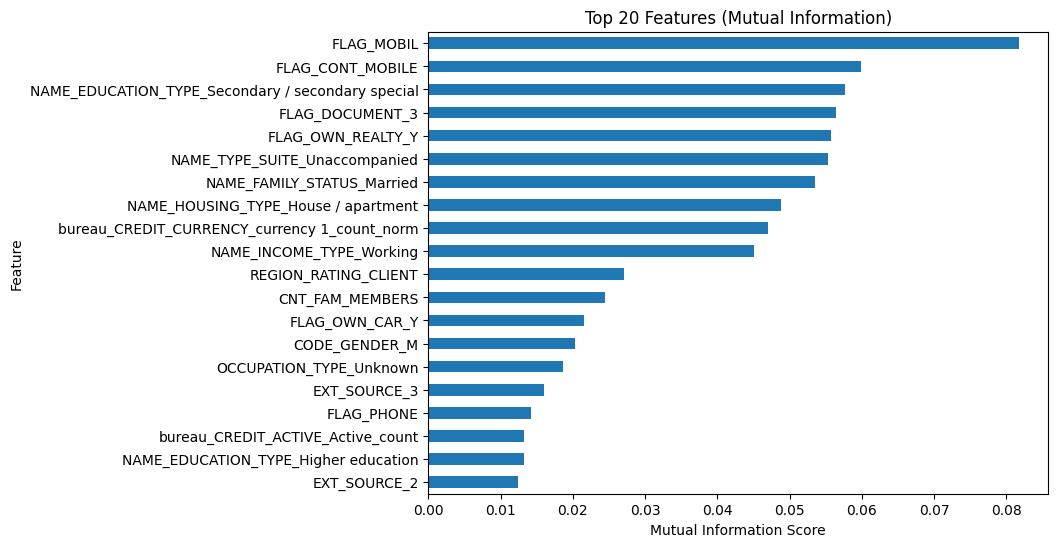

In [15]:
# Plotting top 20 features based on Mutual Information
top20_mi.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 20 Features (Mutual Information)")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.show()

In [16]:
# Sample 20,000 rows For RandomForest for feature selection
from sklearn.ensemble import RandomForestClassifier

Xs = X2.sample(20000, random_state=42)
ys = y.loc[Xs.index]

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight="balanced")
rf.fit(Xs, ys)

print("Done")


Done


**Feature Selection Using Random Forest**

Random Forest is a model-based feature selection method. It builds many decision trees and learns patterns from the data. After training, it gives an importance score to each feature based on how much it helps in predicting the TARGET variable. We use these importance scores to identify the top 20 most important variables. For computational efficiency, we train the Random Forest model on a sample of 20,000 rows instead of the full dataset.
This sample is used as a practical example to reduce training time.

In [17]:
# Extracting and ranking feature importance scores from Random Forest
imp = pd.Series(rf.feature_importances_, index=Xs.columns).sort_values(ascending=False)
top20 = imp.head(20)

top20


,0
EXT_SOURCE_2,0.057828
EXT_SOURCE_3,0.038663
DAYS_BIRTH,0.029663
DAYS_EMPLOYED,0.027121
DAYS_LAST_PHONE_CHANGE,0.026410
DAYS_REGISTRATION,0.024802
DAYS_ID_PUBLISH,0.024408
AMT_ANNUITY,0.024374
AMT_CREDIT,0.023721
SK_ID_CURR,0.023630


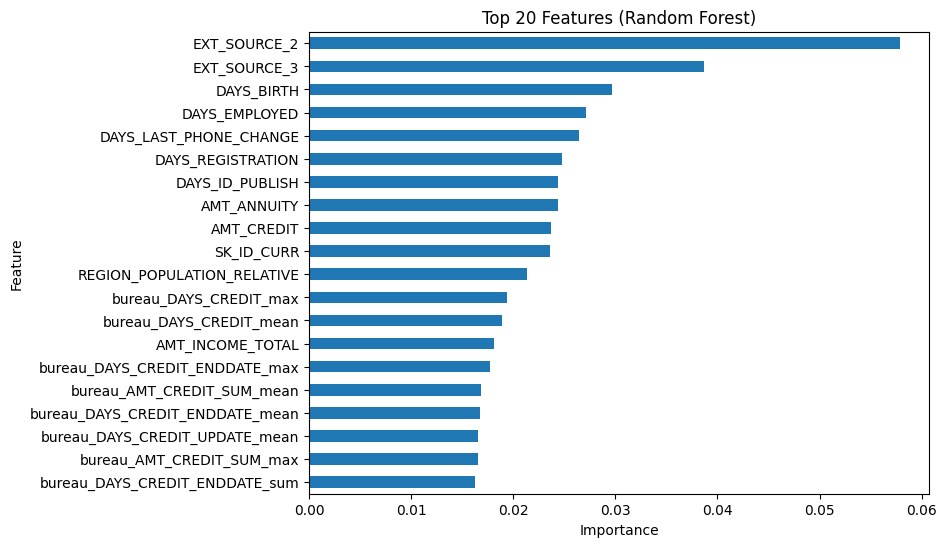

In [18]:
# Plot top 20 features based on Random Forest importance
top20.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Top 20 Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


In [19]:
# Top 20 features selected by Mutual Information
final20_mi = list(top20_mi.index)

# Displaying the final selected features from Mutual Information
final20_mi

['FLAG_MOBIL',
 'FLAG_CONT_MOBILE',
 'NAME_EDUCATION_TYPE_Secondary / secondary special',
 'FLAG_DOCUMENT_3',
 'FLAG_OWN_REALTY_Y',
 'NAME_TYPE_SUITE_Unaccompanied',
 'NAME_FAMILY_STATUS_Married',
 'NAME_HOUSING_TYPE_House / apartment',
 'bureau_CREDIT_CURRENCY_currency 1_count_norm',
 'NAME_INCOME_TYPE_Working',
 'REGION_RATING_CLIENT',
 'CNT_FAM_MEMBERS',
 'FLAG_OWN_CAR_Y',
 'CODE_GENDER_M',
 'OCCUPATION_TYPE_Unknown',
 'EXT_SOURCE_3',
 'FLAG_PHONE',
 'bureau_CREDIT_ACTIVE_Active_count',
 'NAME_EDUCATION_TYPE_Higher education',
 'EXT_SOURCE_2']

In [20]:
# Top 20 features selected by Random Forest
final20_rf = list(top20.index)

# Displaying the final selected features from Random Forest
final20_rf

['EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_LAST_PHONE_CHANGE',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'AMT_ANNUITY',
 'AMT_CREDIT',
 'SK_ID_CURR',
 'REGION_POPULATION_RELATIVE',
 'bureau_DAYS_CREDIT_max',
 'bureau_DAYS_CREDIT_mean',
 'AMT_INCOME_TOTAL',
 'bureau_DAYS_CREDIT_ENDDATE_max',
 'bureau_AMT_CREDIT_SUM_mean',
 'bureau_DAYS_CREDIT_ENDDATE_mean',
 'bureau_DAYS_CREDIT_UPDATE_mean',
 'bureau_AMT_CREDIT_SUM_max',
 'bureau_DAYS_CREDIT_ENDDATE_sum']

In [21]:
print("Original:", df.shape)
print("After missing drop:", df1.shape)
print("After corr drop:", df2.shape)
print("After encoding:", X2.shape)
print("Final features as per Mutual Information:", len(final20_mi))
print("Final features as per Random Forest:", len(final20_rf))

Original: (307511, 302)
After missing drop: (307511, 184)
After corr drop: (307511, 160)
After encoding: (307511, 261)
Final features as per Mutual Information: 20
Final features as per Random Forest: 20


**Business Conclusion**

In Part-1 we reduced the model to the 20 most important features using statistical and model-based methods. This makes the model simpler, faster, and easier to maintain. A smaller set of features also improves transparency and makes it easier to explain decisions to regulators. By removing redundant and less useful variables, we improve clarity without losing the main predictive power of the model. Even if there is a small drop in accuracy, a simpler and more explainable model is preferred in financial risk analysis where trust and compliance are very important.

# **PART-2**

In [22]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

from google.colab import files
uploaded = files.upload()

Saving Crimes_One_year_prior_to_present.csv to Crimes_One_year_prior_to_present.csv


In [23]:
df = pd.read_csv("Crimes_One_year_prior_to_present.csv")

In [24]:
print("Shape:", df.shape)

Shape: (213889, 17)


In [25]:
print("\nColumns:\n", df.columns)


Columns:
 Index(['CASE#', 'DATE  OF OCCURRENCE', 'BLOCK', ' IUCR',
       ' PRIMARY DESCRIPTION', ' SECONDARY DESCRIPTION',
       ' LOCATION DESCRIPTION', 'ARREST', 'DOMESTIC', 'BEAT', 'WARD', 'FBI CD',
       'X COORDINATE', 'Y COORDINATE', 'LATITUDE', 'LONGITUDE', 'LOCATION'],
      dtype='object')


In [26]:
df.head()

,CASE#,DATE OF OCCURRENCE,BLOCK,IUCR,PRIMARY DESCRIPTION,SECONDARY DESCRIPTION,LOCATION DESCRIPTION,ARREST,DOMESTIC,BEAT,WARD,FBI CD,X COORDINATE,Y COORDINATE,LATITUDE,LONGITUDE,LOCATION
0,JF244841,08/15/2021 12:00:00 AM,027XX S SPRINGFIELD AVE,2826,OTHER OFFENSE,HARASSMENT BY ELECTRONIC MEANS,APARTMENT,N,N,1031,22.0,26,NaN,NaN,NaN,NaN,NaN
1,JF121694,12/07/2021 01:00:00 PM,052XX S BLACKSTONE AVE,0820,THEFT,$500 AND UNDER,STREET,N,N,234,4.0,06,NaN,NaN,NaN,NaN,NaN
2,JE446397,11/15/2021 12:00:00 AM,020XX W 52ND ST,1750,OFFENSE INVOLVING CHILDREN,CHILD ABUSE,RESIDENCE,N,Y,932,16.0,08B,NaN,NaN,NaN,NaN,NaN
3,JF156654,11/01/2021 12:00:00 AM,020XX W ARMITAGE AVE,1120,DECEPTIVE PRACTICE,FORGERY,GAS STATION,N,N,1432,32.0,10,NaN,NaN,NaN,NaN,NaN
4,JF104823,12/30/2021 03:45:00 PM,017XX N CICERO AVE,1206,DECEPTIVE PRACTICE,"THEFT BY LESSEE, MOTOR VEHICLE",COMMERCIAL / BUSINESS OFFICE,N,N,2533,37.0,11,NaN,NaN,NaN,NaN,NaN


In [27]:
# Checking missing values
print("Missing values per column:")
print(df.isna().sum())

# Check duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
CASE#                        0
DATE  OF OCCURRENCE          0
BLOCK                        0
 IUCR                        0
 PRIMARY DESCRIPTION         0
 SECONDARY DESCRIPTION       0
 LOCATION DESCRIPTION      657
ARREST                       0
DOMESTIC                     0
BEAT                         0
WARD                        12
FBI CD                       0
X COORDINATE              3844
Y COORDINATE              3844
LATITUDE                  3844
LONGITUDE                 3844
LOCATION                  3844
dtype: int64

Duplicate rows: 9


In [28]:
print("\nShape before cleaning:", df.shape)

# Dropping duplicates
df = df.drop_duplicates()

# Drop rows with any missing values
df = df.dropna()

print("Shape after dropping missing values & duplicates:", df.shape)


Shape before cleaning: (213889, 17)
Shape after dropping missing values & duplicates: (209535, 17)


In [29]:
# Checking missing values again
print("Missing values per column:")
print(df.isna().sum())

# Checking duplicate rows again
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
CASE#                     0
DATE  OF OCCURRENCE       0
BLOCK                     0
 IUCR                     0
 PRIMARY DESCRIPTION      0
 SECONDARY DESCRIPTION    0
 LOCATION DESCRIPTION     0
ARREST                    0
DOMESTIC                  0
BEAT                      0
WARD                      0
FBI CD                    0
X COORDINATE              0
Y COORDINATE              0
LATITUDE                  0
LONGITUDE                 0
LOCATION                  0
dtype: int64

Duplicate rows: 0


The DATE OF OCCURRENCE column is stored as a timestamp, which a machine learning model cannot understand directly. By extracting Hour_of_Day, Day_of_Week, and Is_Weekend, we convert the raw date into useful time-based features.

These features help the model learn patterns such as whether arrests are more likely at certain hours or on weekends. From a business perspective, this helps SafeCity Solutions identify high-risk time periods and recommend better patrol planning and resource allocation.

In [30]:
# Define the correct date column name
date_column = 'DATE  OF OCCURRENCE'

# Parse the date column into a proper datetime object with the correct format
df[date_column] = pd.to_datetime(df[date_column], format='%m/%d/%Y %I:%M:%S %p',errors='coerce')

df['Hour_of_Day'] = df[date_column].dt.hour

df['Day_of_Week'] = df[date_column].dt.day_name()

df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

df[[date_column, 'Hour_of_Day', 'Day_of_Week', 'Is_Weekend']].head(6)

,DATE OF OCCURRENCE,Hour_of_Day,Day_of_Week,Is_Weekend
5,2021-06-15 09:30:00,9,Tuesday,0
6,2021-06-15 07:50:00,7,Tuesday,0
8,2021-06-15 21:01:00,21,Tuesday,0
9,2021-06-15 07:47:00,7,Tuesday,0
10,2021-06-15 01:55:00,1,Tuesday,0
11,2021-06-15 09:20:00,9,Tuesday,0


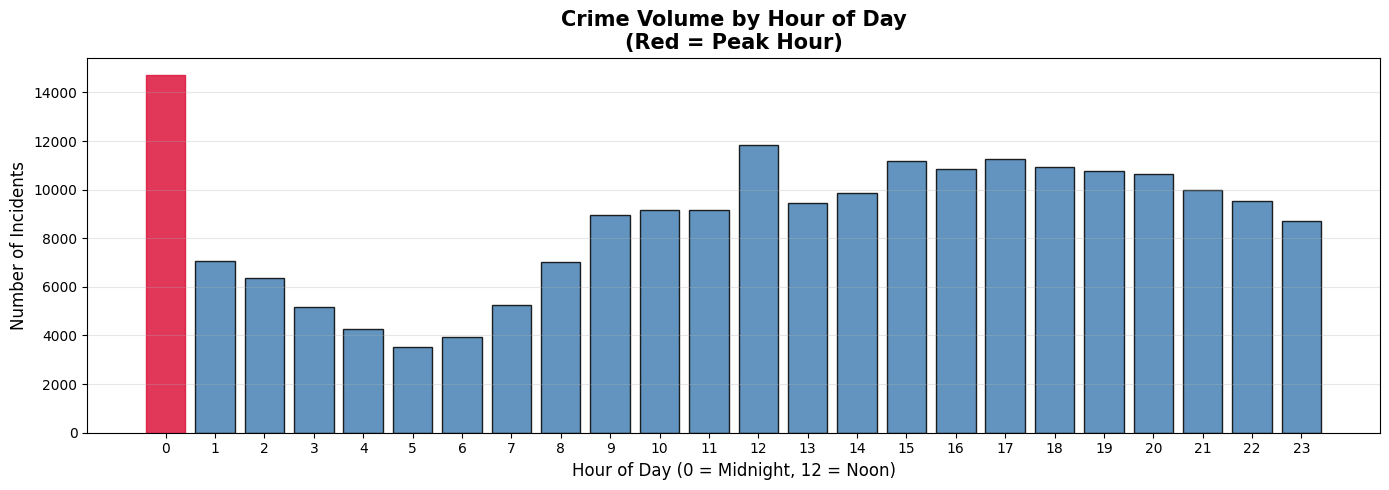

Peak crime hour: 0:00 — 14,701 incidents


In [31]:
# Plot of Crime volume by Hour of day
hourly_counts = df['Hour_of_Day'].value_counts().sort_index()
peak_hour = hourly_counts.idxmax()

plt.figure(figsize=(14, 5))
bars = plt.bar(hourly_counts.index, hourly_counts.values,
               color='steelblue', edgecolor='black', alpha=0.85)

# Peak hour in red
bars[peak_hour].set_color('crimson')

plt.title('Crime Volume by Hour of Day\n(Red = Peak Hour)', fontsize=15, fontweight='bold')
plt.xlabel('Hour of Day (0 = Midnight, 12 = Noon)', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak crime hour: {peak_hour}:00 — {hourly_counts[peak_hour]:,} incidents")

In [32]:
# All unique crime types
print(df[' PRIMARY DESCRIPTION'].value_counts().to_string())

 PRIMARY DESCRIPTION
THEFT                                44372
BATTERY                              41414
CRIMINAL DAMAGE                      24905
ASSAULT                              20595
OTHER OFFENSE                        14028
DECEPTIVE PRACTICE                   12631
MOTOR VEHICLE THEFT                  11920
WEAPONS VIOLATION                     8837
ROBBERY                               8408
BURGLARY                              7294
CRIMINAL TRESPASS                     3745
NARCOTICS                             3516
OFFENSE INVOLVING CHILDREN            1829
CRIMINAL SEXUAL ASSAULT               1466
SEX OFFENSE                           1133
HOMICIDE                               786
PUBLIC PEACE VIOLATION                 656
ARSON                                  473
STALKING                               365
INTERFERENCE WITH PUBLIC OFFICER       331
PROSTITUTION                           204
CONCEALED CARRY LICENSE VIOLATION      178
LIQUOR LAW VIOLATION             

The PRIMARY DESCRIPTION column contains many different crime types. If we use all of them separately, the model becomes too complicated and harder to understand. By grouping the crimes into three main categories (Violent Crime, Property Crime, and Public Order/Other), we make the data simpler and easier for the model to learn patterns. From a business point of view, these broader categories are easier to explain and help decision-makers quickly understand crime trends and plan resources better.

In [33]:
#Grouping 20+ specific crime types into 3 broad buckets
violent_crimes = [
    'BATTERY', 'ASSAULT', 'ROBBERY', 'HOMICIDE',
    'CRIMINAL SEXUAL ASSAULT', 'SEX OFFENSE', 'KIDNAPPING',
    'OFFENSE INVOLVING CHILDREN', 'STALKING', 'INTIMIDATION',
    'HUMAN TRAFFICKING', 'ARSON'
]

property_crimes = [
    'THEFT', 'BURGLARY', 'MOTOR VEHICLE THEFT',
    'CRIMINAL DAMAGE', 'DECEPTIVE PRACTICE'
]

# Everything else falls into Public Order / Other
def categorize_crime(crime_type):
    if crime_type in violent_crimes:
        return 'Violent Crime'
    elif crime_type in property_crimes:
        return 'Property Crime'
    else:
        return 'Public Order/Other'

df['Crime_Category'] = df[' PRIMARY DESCRIPTION'].apply(categorize_crime)

# Print distribution
print(df['Crime_Category'].value_counts())
print(f"\nTotal rows: {len(df)}")

# Code partially generated using ChatGPT prompt: "Group multiple crime types into Violent, Property, and Public Order categories in pandas"

Crime_Category
Property Crime        101122
Violent Crime          76690
Public Order/Other     31723
Name: count, dtype: int64

Total rows: 209535


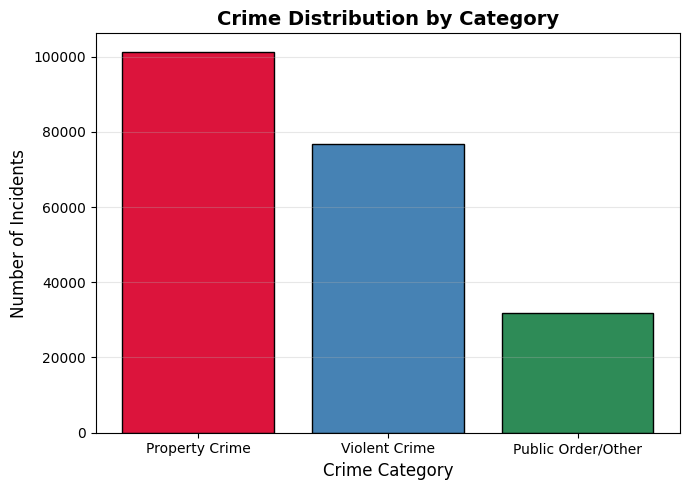

In [34]:
# Plotting Crime distribution by category
cat_counts = df['Crime_Category'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(cat_counts.index, cat_counts.values,
        color=['crimson', 'steelblue', 'seagreen'], edgecolor='black')
plt.title('Crime Distribution by Category', fontsize=14, fontweight='bold')
plt.xlabel('Crime Category', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Create a Risk_Level feature by counting crimes in each WARD (or BEAT) and dividing areas into Low, Medium, and High risk based on crime frequency
area_col = "WARD" if "WARD" in df.columns else "BEAT"

area_counts = df[area_col].value_counts()

low_thresh = area_counts.quantile(0.33)
high_thresh = area_counts.quantile(0.66)

def risk_level(area):
    count = area_counts.get(area, 0)
    if count <= low_thresh:
        return "Low"
    elif count <= high_thresh:
        return "Medium"
    else:
        return "High"

df["Risk_Level"] = df[area_col].apply(risk_level)

df["Risk_Level"].value_counts()
# Code partially generated using ChatGPT prompt: "Create categorical risk levels from frequency counts in pandas"

,count
Risk_Level,
High,119018
Medium,52661
Low,37856


We use the WARD and BEAT columns to understand which areas have more crimes. Instead of using exact coordinates, we count how many crimes happened in each ward (or beat) and label them as Low, Medium, or High risk. This makes the data easier to understand and prevents the model from memorizing exact locations. From a business point of view, this helps identify high-risk areas and supports better planning and resource allocation.

In [36]:
# Drop raw coordinates to prevent overfitting to precise locations
coords_to_drop = ['X COORDINATE', 'Y COORDINATE']
df.drop(columns=coords_to_drop, inplace=True)

print("Dropped columns:", coords_to_drop)
print("Remaining columns:", df.columns.tolist())

Dropped columns: ['X COORDINATE', 'Y COORDINATE']
Remaining columns: ['CASE#', 'DATE  OF OCCURRENCE', 'BLOCK', ' IUCR', ' PRIMARY DESCRIPTION', ' SECONDARY DESCRIPTION', ' LOCATION DESCRIPTION', 'ARREST', 'DOMESTIC', 'BEAT', 'WARD', 'FBI CD', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'Hour_of_Day', 'Day_of_Week', 'Is_Weekend', 'Crime_Category', 'Risk_Level']


Machine learning models can only work with numbers, so we need to convert certain columns into numeric form. The LOCATION DESCRIPTION column contains text values such as APARTMENT or STREET, so we use one-hot encoding to turn these categories into 0 and 1 values. We also standardize the Latitude and Longitude values so the model treats location data properly and fairly. Finally, the ARREST and DOMESTIC columns are stored as 0 and 1 to ensure they can be used correctly in the model.

In [37]:
# Converting ARREST and DOMESTIC from Y/N to 1/0
df['ARREST']   = df['ARREST'].map({'Y': 1, 'N': 0})
df['DOMESTIC'] = df['DOMESTIC'].map({'Y': 1, 'N': 0})

print("ARREST value counts:\n",  df['ARREST'].value_counts())
print("\nDOMESTIC value counts:\n", df['DOMESTIC'].value_counts())

ARREST value counts:
 ARREST
0    185387
1     24148
Name: count, dtype: int64

DOMESTIC value counts:
 DOMESTIC
0    165890
1     43645
Name: count, dtype: int64


In [38]:
# Doing one One-Hot encoding on LOCATION DESCRIPTION
location_dummies = pd.get_dummies(df[' LOCATION DESCRIPTION'], prefix="LOC").astype(int)

df.drop(columns=[' LOCATION DESCRIPTION'], inplace=True)

df = pd.concat([df, location_dummies], axis=1)

df.filter(like="LOC_").head()

,LOC_ABANDONED BUILDING,LOC_AIRCRAFT,LOC_AIRPORT BUILDING NON-TERMINAL - NON-SECURE AREA,LOC_AIRPORT BUILDING NON-TERMINAL - SECURE AREA,LOC_AIRPORT EXTERIOR - NON-SECURE AREA,LOC_AIRPORT EXTERIOR - SECURE AREA,LOC_AIRPORT PARKING LOT,LOC_AIRPORT TERMINAL LOWER LEVEL - NON-SECURE AREA,LOC_AIRPORT TERMINAL LOWER LEVEL - SECURE AREA,LOC_AIRPORT TERMINAL MEZZANINE - NON-SECURE AREA,...,LOC_VACANT LOT / LAND,LOC_VEHICLE - COMMERCIAL,LOC_VEHICLE - COMMERCIAL: ENTERTAINMENT / PARTY BUS,LOC_VEHICLE - COMMERCIAL: TROLLEY BUS,LOC_VEHICLE - DELIVERY TRUCK,"LOC_VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)",LOC_VEHICLE NON-COMMERCIAL,LOC_VESTIBULE,LOC_WAREHOUSE,LOC_YARD
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
# Apply Z-score standardization to LATITUDE and LONGITUDE columns
scaler = StandardScaler()
df[['LATITUDE_scaled', 'LONGITUDE_scaled']] = scaler.fit_transform(
    df[['LATITUDE', 'LONGITUDE']]
)

df.drop(columns=['LATITUDE', 'LONGITUDE'], inplace=True)

print("Scaled coordinate stats:")
print(df[['LATITUDE_scaled', 'LONGITUDE_scaled']].describe())
df.head(3)

Scaled coordinate stats:
       LATITUDE_scaled  LONGITUDE_scaled
count     2.095350e+05      2.095350e+05
mean      5.149462e-14     -4.488802e-14
std       1.000002e+00      1.000002e+00
min      -2.277160e+00     -4.532168e+00
25%      -8.680765e-01     -7.021744e-01
50%       1.851425e-01      1.202947e-01
75%       7.245745e-01      7.026438e-01
max       2.043902e+00      2.412350e+00


,CASE#,DATE OF OCCURRENCE,BLOCK,IUCR,PRIMARY DESCRIPTION,SECONDARY DESCRIPTION,ARREST,DOMESTIC,BEAT,WARD,...,LOC_VEHICLE - COMMERCIAL: ENTERTAINMENT / PARTY BUS,LOC_VEHICLE - COMMERCIAL: TROLLEY BUS,LOC_VEHICLE - DELIVERY TRUCK,"LOC_VEHICLE - OTHER RIDE SHARE SERVICE (LYFT, UBER, ETC.)",LOC_VEHICLE NON-COMMERCIAL,LOC_VESTIBULE,LOC_WAREHOUSE,LOC_YARD,LATITUDE_scaled,LONGITUDE_scaled
5,JE266628,2021-06-15 09:30:00,080XX S DREXEL AVE,0820,THEFT,$500 AND UNDER,0,0,631,8.0,...,0,0,0,0,0,0,0,0,-1.089499,1.105319
6,JE266536,2021-06-15 07:50:00,042XX W MADISON ST,0560,ASSAULT,SIMPLE,0,0,1115,28.0,...,0,0,0,0,0,0,0,0,0.421680,-1.044107
8,JE267466,2021-06-15 21:01:00,007XX S KEDZIE AVE,051B,ASSAULT,AGGRAVATED - OTHER FIREARM,1,0,1134,24.0,...,0,0,0,0,0,0,0,0,0.317404,-0.620154


In [40]:
print("Final Shape:", df.shape)

Final Shape: (209535, 148)
